In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, train_test_split,StratifiedKFold, learning_curve,cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import randint, uniform


In [2]:
df = pd.read_csv('profit_estimation_10k.csv')
df.head()

,crop,area_feddans,season,soil_type,region,seed_cost_egp,fertilizer_cost_egp,irrigation_cost_egp,labor_cost_egp,pesticide_cost_egp,profit_per_feddan_egp,price_egp_per_ton
0,Cotton,84,Nile,Loamy,Upper_Egypt,28146,17236,17183,5507,5952,18401,30543
1,Fava Beans,8,Winter,Loamy,Upper_Egypt,194,8266,14398,11285,7699,18943,44480
2,Rice,100,Summer,Loamy,Delta,77175,60935,68587,53294,29437,82792,23372
3,Cotton,10,Summer,Clay,NewLands,10295,8372,5470,7147,4727,15021,31986
4,Potato,89,Winter,Loamy,North_Coast,20396,9394,10383,20658,19299,35193,5807


In [3]:
df.shape

(10400, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   crop                   10400 non-null  object
 1   area_feddans           10400 non-null  int64 
 2   season                 10400 non-null  object
 3   soil_type              10400 non-null  object
 4   region                 10400 non-null  object
 5   seed_cost_egp          10400 non-null  int64 
 6   fertilizer_cost_egp    10400 non-null  int64 
 7   irrigation_cost_egp    10400 non-null  int64 
 8   labor_cost_egp         10400 non-null  int64 
 9   pesticide_cost_egp     10400 non-null  int64 
 10  profit_per_feddan_egp  10400 non-null  int64 
 11  price_egp_per_ton      10400 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 975.1+ KB


In [5]:
print(df.isna().sum())

crop                     0
area_feddans             0
season                   0
soil_type                0
region                   0
seed_cost_egp            0
fertilizer_cost_egp      0
irrigation_cost_egp      0
labor_cost_egp           0
pesticide_cost_egp       0
profit_per_feddan_egp    0
price_egp_per_ton        0
dtype: int64


In [6]:
df.duplicated().sum()

np.int64(0)

# **EDA**

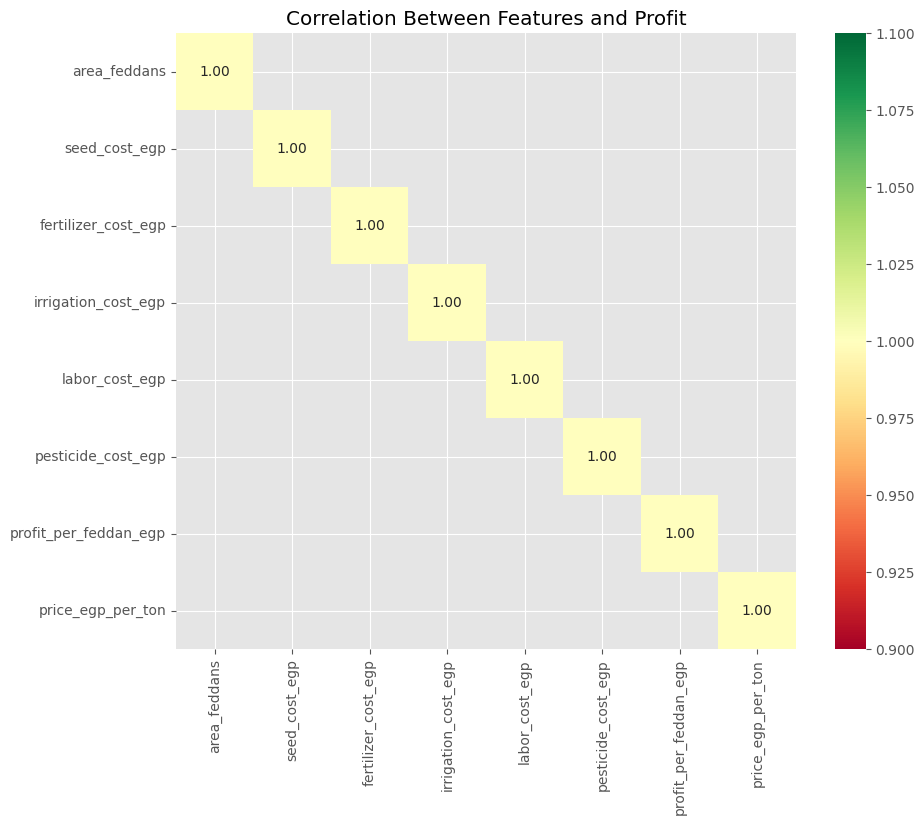

In [7]:
plt.style.use('ggplot')
sns.set_palette("viridis")
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f",mask=correlation_matrix < 0.85)
plt.title('Correlation Between Features and Profit')
plt.show()

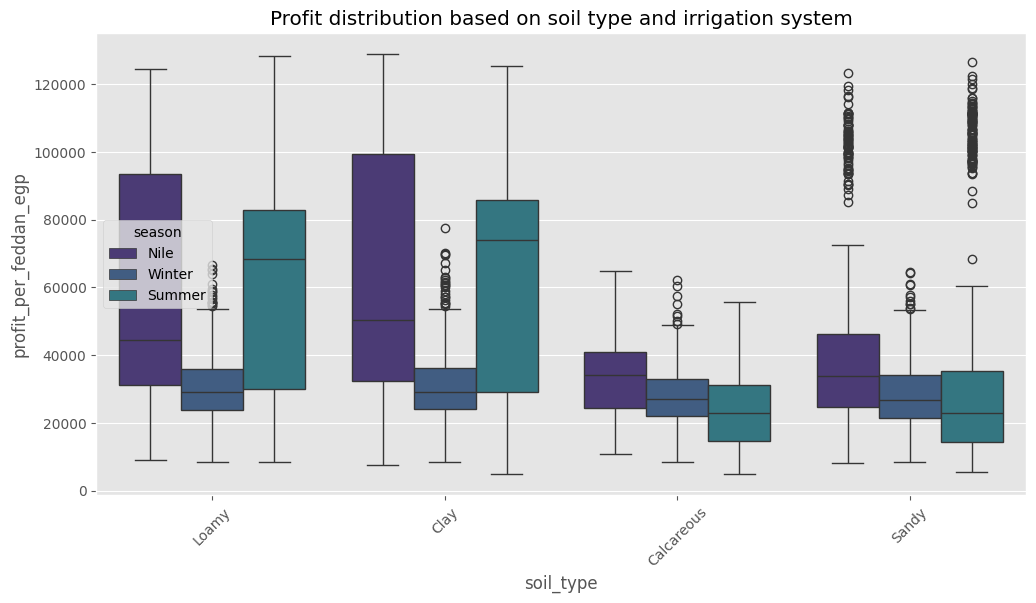

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='soil_type', y='profit_per_feddan_egp', hue='season', data=df)
plt.title('Profit distribution based on soil type and irrigation system')
plt.xticks(rotation=45)
plt.show()

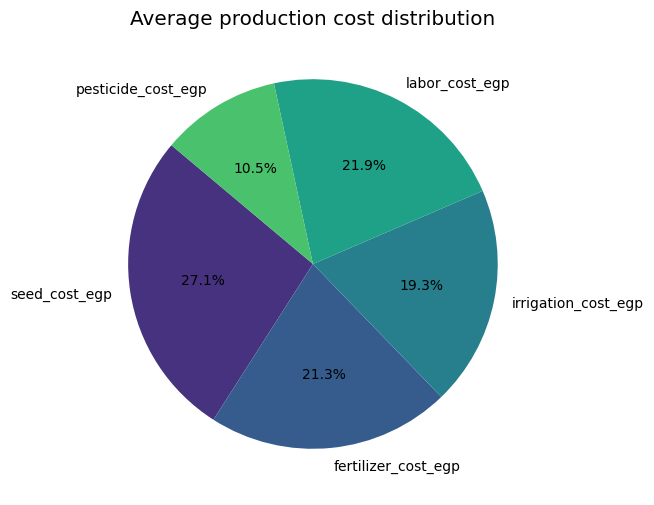

In [9]:
cost_columns = ['seed_cost_egp', 'fertilizer_cost_egp', 'irrigation_cost_egp', 
                'labor_cost_egp', 'pesticide_cost_egp']
mean_costs = df[cost_columns].mean()

plt.figure(figsize=(10, 6))
mean_costs.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Average production cost distribution')
plt.show()

In [10]:
df.columns

Index(['crop', 'area_feddans', 'season', 'soil_type', 'region',
       'seed_cost_egp', 'fertilizer_cost_egp', 'irrigation_cost_egp',
       'labor_cost_egp', 'pesticide_cost_egp', 'profit_per_feddan_egp',
       'price_egp_per_ton'],
      dtype='object')

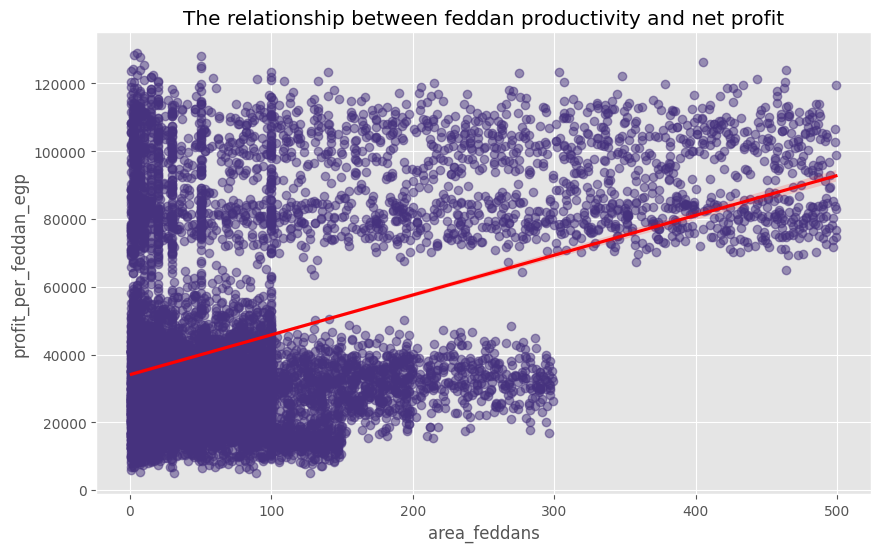

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x='area_feddans', y='profit_per_feddan_egp', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('The relationship between feddan productivity and net profit')
plt.show()

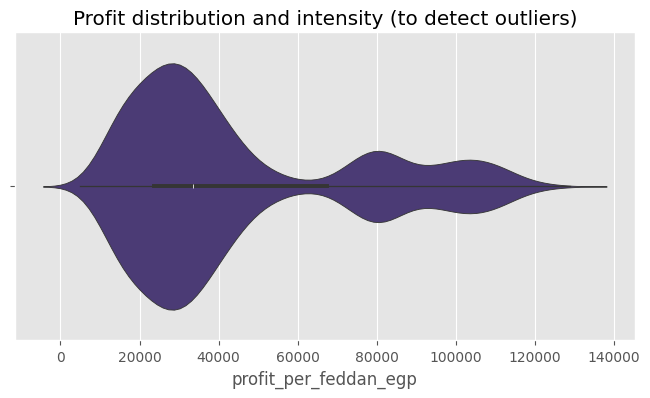

In [12]:
plt.figure(figsize=(8, 4))
sns.violinplot(x=df['profit_per_feddan_egp'])
plt.title('Profit distribution and intensity (to detect outliers)')
plt.show()

# **Explore Outliers**

In [13]:
num = df.select_dtypes(include=['int64','float64'])
num

,area_feddans,seed_cost_egp,fertilizer_cost_egp,irrigation_cost_egp,labor_cost_egp,pesticide_cost_egp,profit_per_feddan_egp,price_egp_per_ton
0,84,28146,17236,17183,5507,5952,18401,30543
1,8,194,8266,14398,11285,7699,18943,44480
2,100,77175,60935,68587,53294,29437,82792,23372
3,10,10295,8372,5470,7147,4727,15021,31986
4,89,20396,9394,10383,20658,19299,35193,5807
...,...,...,...,...,...,...,...,...
10395,338,4288,27498,24332,32522,13733,91575,22507
10396,341,32030,17762,32179,22115,9024,81708,22730
10397,370,48595,3596,35501,27296,13935,78860,23861
10398,30,51385,49078,39366,58479,14727,99744,2500


In [14]:
for col in num:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    
    Lp = q1 - 1.5 * iqr
    Up = q3 + 1.5 * iqr 
    
    Outlier = df[(df[col] < Lp ) | (df[col] > Up)].shape[0]
    
    print(f'---- {col} ----')
    print(f'{col} outlier : {Outlier} , Lower = {Lp} , Upper = {Up}')
    print('--' * 20)

---- area_feddans ----
area_feddans outlier : 964 , Lower = -131.0 , Upper = 261.0
----------------------------------------
---- seed_cost_egp ----
seed_cost_egp outlier : 464 , Lower = -37150.25 , Upper = 75373.75
----------------------------------------
---- fertilizer_cost_egp ----
fertilizer_cost_egp outlier : 548 , Lower = -29124.375 , Upper = 58788.625
----------------------------------------
---- irrigation_cost_egp ----
irrigation_cost_egp outlier : 611 , Lower = -26481.25 , Upper = 52774.75
----------------------------------------
---- labor_cost_egp ----
labor_cost_egp outlier : 669 , Lower = -29348.625 , Upper = 58524.375
----------------------------------------
---- pesticide_cost_egp ----
pesticide_cost_egp outlier : 412 , Lower = -14791.875 , Upper = 29843.125
----------------------------------------
---- profit_per_feddan_egp ----
profit_per_feddan_egp outlier : 0 , Lower = -41840.25 , Upper = 132857.75
----------------------------------------
---- price_egp_per_ton ----

# **Encoding Categorical Features**

In [15]:
crop_map = {"Wheat": 0, "Rice": 1, "Maize": 2, "Cotton": 3, "Sugarcane": 4, "Tomato": 5, "Potato": 6, "Fava Beans": 7}
soil_map = {"Clay": 0, "Loamy": 1, "Calcareous": 2, "Sandy": 3}
region_map = {"Delta": 0, "Upper_Egypt": 1, "North_Coast": 2, "Sinai": 3, "NewLands": 4}
season_map = {"Winter": 0, "Summer": 1, "Nile": 2}

df['soil_type'] = df['soil_type'].map(soil_map)
df['region'] = df['region'].map(region_map)
df['season'] = df['season'].map(season_map)
df['crop'] = df['crop'].map(crop_map)

In [16]:
df.head()

,crop,area_feddans,season,soil_type,region,seed_cost_egp,fertilizer_cost_egp,irrigation_cost_egp,labor_cost_egp,pesticide_cost_egp,profit_per_feddan_egp,price_egp_per_ton
0,3,84,2,1,1,28146,17236,17183,5507,5952,18401,30543
1,7,8,0,1,1,194,8266,14398,11285,7699,18943,44480
2,1,100,1,1,0,77175,60935,68587,53294,29437,82792,23372
3,3,10,1,0,4,10295,8372,5470,7147,4727,15021,31986
4,6,89,0,1,2,20396,9394,10383,20658,19299,35193,5807


In [17]:
print(df[['soil_type', 'region', 'season', 'crop']].isnull().sum())

soil_type    0
region       0
season       0
crop         0
dtype: int64


# **Data Split**

In [18]:
x = df.drop(['profit_per_feddan_egp','price_egp_per_ton'],axis=1)
y = df['profit_per_feddan_egp']

In [19]:
x

,crop,area_feddans,season,soil_type,region,seed_cost_egp,fertilizer_cost_egp,irrigation_cost_egp,labor_cost_egp,pesticide_cost_egp
0,3,84,2,1,1,28146,17236,17183,5507,5952
1,7,8,0,1,1,194,8266,14398,11285,7699
2,1,100,1,1,0,77175,60935,68587,53294,29437
3,3,10,1,0,4,10295,8372,5470,7147,4727
4,6,89,0,1,2,20396,9394,10383,20658,19299
...,...,...,...,...,...,...,...,...,...,...
10395,1,338,1,1,0,4288,27498,24332,32522,13733
10396,1,341,2,0,2,32030,17762,32179,22115,9024
10397,1,370,1,0,0,48595,3596,35501,27296,13935
10398,4,30,1,0,1,51385,49078,39366,58479,14727


In [20]:
y

0        18401
1        18943
2        82792
3        15021
4        35193
         ...  
10395    91575
10396    81708
10397    78860
10398    99744
10399    33849
Name: profit_per_feddan_egp, Length: 10400, dtype: int64

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8320, 10)
(2080, 10)
(8320,)
(2080,)


# **Model**

In [22]:
xgb_params = {
    'n_estimators':     randint(200, 800),
    'max_depth':        randint(3, 9),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma':            uniform(0, 3),
    'reg_alpha':        uniform(0, 2),
    'reg_lambda':       uniform(1, 4),
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=30,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train)

xgb_best = xgb_search.best_estimator_
xgb_train_r2 = round(xgb_best.score(x_train, y_train), 4)
xgb_test_r2  = round(xgb_best.score(x_test,  y_test),  4)
xgb_mae      = round(mean_absolute_error(y_test, xgb_best.predict(x_test)), 0)

print(f"best params: {xgb_search.best_params_}")
print(f"train R²: {xgb_train_r2}  |  test R²: {xgb_test_r2}  |  MAE: {xgb_mae}  |  gap: {round(xgb_train_r2 - xgb_test_r2, 4)}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
best params: {'colsample_bytree': np.float64(0.8493192507310232), 'gamma': np.float64(0.9926940745579476), 'learning_rate': np.float64(0.02271167005720473), 'max_depth': 8, 'min_child_weight': 8, 'n_estimators': 298, 'reg_alpha': np.float64(1.1825955754154542), 'reg_lambda': np.float64(2.0988871719602566), 'subsample': np.float64(0.8244973703390804)}
train R²: 0.965  |  test R²: 0.9306  |  MAE: 5909.0  |  gap: 0.0344


In [23]:
df['profit_per_feddan_egp'].mean()

np.float64(44900.59201923077)

# **Evaluation**

In [24]:
y_train_pred = xgb_best.predict(x_train)
y_test_pred  = xgb_best.predict(x_test)

train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)
train_mae  = mean_absolute_error(y_train, y_train_pred)
test_mae   = mean_absolute_error(y_test,  y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

print(f"train  →  R²: {train_r2:.4f}  MAE: {train_mae:.0f}  RMSE: {train_rmse:.0f}")
print(f"test   →  R²: {test_r2:.4f}  MAE: {test_mae:.0f}  RMSE: {test_rmse:.0f}")

gap = train_r2 - test_r2
status = "overfit" if gap > 0.1 else ("underfit" if gap < -0.05 else "ok")
print(f"gap: {gap:.4f}  ({status})")

train  →  R²: 0.9650  MAE: 4234  RMSE: 5531
test   →  R²: 0.9306  MAE: 5909  RMSE: 7861
gap: 0.0344  (ok)


In [25]:
cv_scores = cross_val_score(xgb_best, x_train, y_train, cv=5, scoring='r2')
print(f"CV scores: {[round(s, 4) for s in cv_scores]}")
print(f"mean: {cv_scores.mean():.4f}  std: {cv_scores.std():.4f}")

CV scores: [np.float64(0.9363), np.float64(0.9305), np.float64(0.9356), np.float64(0.9297), np.float64(0.9365)]
mean: 0.9337  std: 0.0030


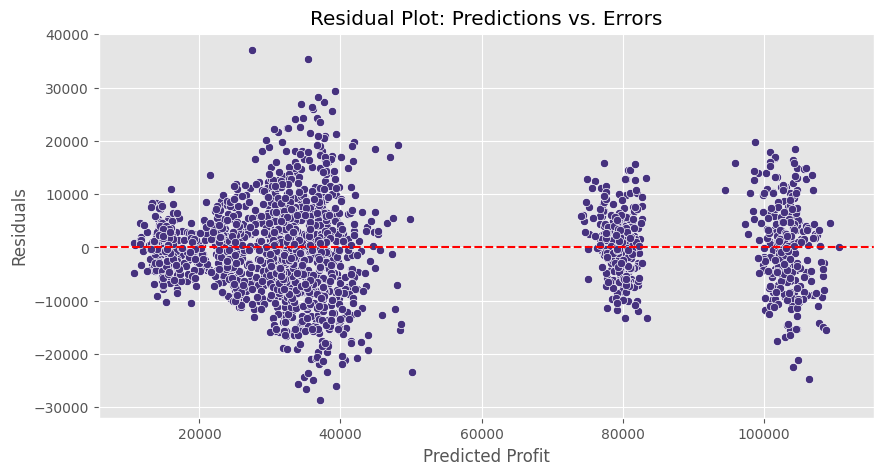

In [26]:
residuals = y_test - xgb_best.predict(x_test)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=xgb_best.predict(x_test), y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot: Predictions vs. Errors')
plt.xlabel('Predicted Profit')
plt.ylabel('Residuals')
plt.show()

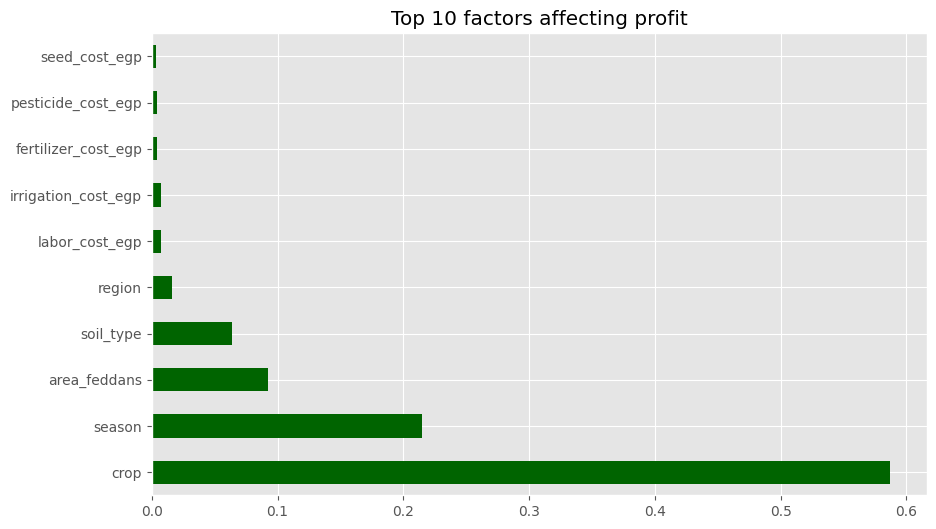

In [27]:
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_best.feature_importances_, index=x_train.columns)
importances.nlargest(10).plot(kind='barh', color='darkgreen')
plt.title('Top 10 factors affecting profit')
plt.show()

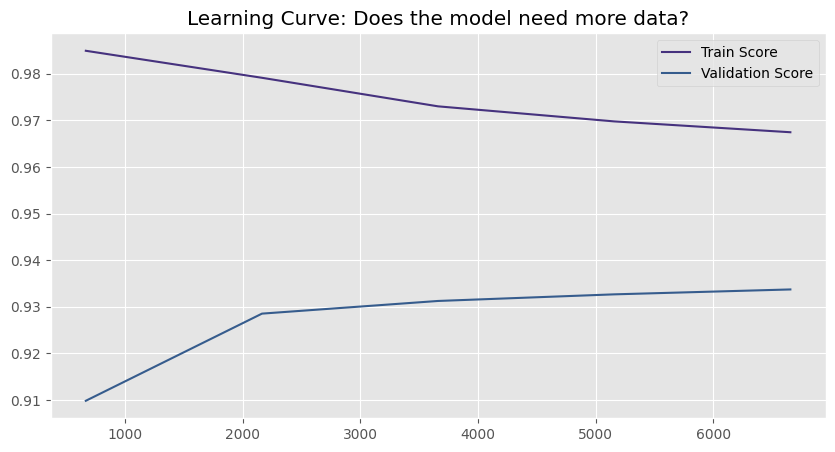

In [28]:
train_sizes, train_scores, test_scores = learning_curve(xgb_best, x_train, y_train, cv=5)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train Score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Score')
plt.title('Learning Curve: Does the model need more data?')
plt.legend()
plt.show()

# **Pkl**

In [29]:
import joblib

joblib.dump({
    'model':      xgb_best,
    'crop_map':   crop_map,
    'season_map': season_map,
    'soil_map':   soil_map,
    'region_map': region_map,
    'features':   x.columns.tolist(),
    'avg_price': {
        'Cotton':     29845,
        'Fava Beans': 44502,
        'Maize':      13024,
        'Potato':     5946,
        'Rice':       23001,
        'Sugarcane':  2500,
        'Tomato':     4418,
        'Wheat':      18411,
    }
}, 'profit_model.pkl')

print("Saved!")

Saved!
